In [ ]:

!pip install kagglehub pandas numpy scikit-learn matplotlib seaborn pyarabic -q

**Load Dataset**

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("abedkhooli/arabic-100k-reviews")
print("الملفات:", os.listdir(path))

الملفات: ['ar_reviews_100k.tsv']


**Read Data**

In [ ]:
import pandas as pd

file_path = r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\arabic-100k-reviews\versions\4\ar_reviews_100k.tsv"

df = pd.read_csv(file_path, sep='\t')

print(f"حجم الداتا: {df.shape}")
print(f"\nتوزيع الفئات:")
print(df['label'].value_counts())
print(f"\nأمثلة:")
print(df.head(3))

حجم الداتا: (99999, 2)

توزيع الفئات:
label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64

أمثلة:
      label                                               text
0  Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1  Positive  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2  Positive  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...


**Text Preprocessing**

In [ ]:
import re
import pyarabic.araby as araby
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

arabic_stopwords = set(stopwords.words('arabic'))

def preprocess_arabic(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = araby.strip_diacritics(text)
    text = araby.normalize_hamza(text)
    text = ' '.join([word for word in text.split() if word not in arabic_stopwords])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess_arabic)

print("قبل المعالجة:")
print(df['text'][0])
print("\nبعد المعالجة:")
print(df['clean_text'][0])
print(f"\nحجم الداتا بعد المعالجة: {df.shape}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


قبل المعالجة:
ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم

بعد المعالجة:
ممتاز نوعا النظافة والموقع والتجهيز والشاطيء المطعم

حجم الداتا بعد المعالجة: (99999, 3)


**Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

label_map = {'Positive': 2, 'Mixed': 1, 'Negative': 0}
df['label_encoded'] = df['label'].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")
print(f"\nتوزيع الـ labels في التدريب:")
print(y_train.value_counts())

df.to_csv(r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\clean_data.csv", 
          index=False, encoding='utf-8-sig')
print("\nتم حفظ الداتا النظيفة ")

Training set: 79984
Test set: 19996

توزيع الـ labels في التدريب:
label_encoded
1    26663
0    26661
2    26660
Name: count, dtype: int64

تم حفظ الداتا النظيفة 


**Baseline Model (SVM)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# تدريب SVM
print("جاري تدريب SVM...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# تقييم
y_pred_svm = svm_model.predict(X_test_tfidf)

print("=== SVM Results ===")
print(classification_report(y_test, y_pred_svm,
      target_names=['Negative', 'Mixed', 'Positive']))

جاري تدريب SVM...
=== SVM Results ===
              precision    recall  f1-score   support

    Negative       0.67      0.71      0.69      6665
       Mixed       0.58      0.51      0.54      6666
    Positive       0.66      0.70      0.68      6665

    accuracy                           0.64     19996
   macro avg       0.64      0.64      0.64     19996
weighted avg       0.64      0.64      0.64     19996



**AraBERT Model**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("جاري تحميل AraBERT...")
model_name = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model = model.to(device)
print("تم تحميل AraBERT ")

X_train_small = X_train[:2000].reset_index(drop=True)
y_train_small = y_train[:2000].reset_index(drop=True)
X_test_small  = X_test[:500].reset_index(drop=True)
y_test_small  = y_test[:500].reset_index(drop=True)

print(f"Training samples: {len(X_train_small)}")
print(f"Test samples: {len(X_test_small)}")

class ArabicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ArabicDataset(X_train_small.tolist(), y_train_small.tolist(), tokenizer)
test_dataset  = ArabicDataset(X_test_small.tolist(),  y_test_small.tolist(),  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)
print("تم تجهيز الداتا ")

Device: cpu
جاري تحميل AraBERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


تم تحميل AraBERT 


**Train AraBERT**

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("\nتم التدريب ")

Epoch 1/3 - Loss: 1.0415
Epoch 2/3 - Loss: 0.7907
Epoch 3/3 - Loss: 0.5879

تم التدريب 


**Evaluate AraBERT**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=== AraBERT Results ===")
print(classification_report(all_labels, all_preds,
      target_names=['Negative', 'Mixed', 'Positive']))

=== AraBERT Results ===
              precision    recall  f1-score   support

    Negative       0.81      0.60      0.69       174
       Mixed       0.48      0.71      0.58       168
    Positive       0.74      0.58      0.65       158

    accuracy                           0.63       500
   macro avg       0.68      0.63      0.64       500
weighted avg       0.68      0.63      0.64       500



**Confusion Matrix - Fair Comparison**

In [ ]:

# (500 samples)
svm_preds_small = svm_model.predict(tfidf.transform(X_test_small))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm_fair = confusion_matrix(y_test_small, svm_preds_small)
sns.heatmap(cm_svm_fair, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Mixed', 'Positive'],
            yticklabels=['Negative', 'Mixed', 'Positive'],
            ax=axes[0])
axes[0].set_title('SVM - Confusion Matrix (500 samples)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_bert_fair = confusion_matrix(y_test_small, all_preds)
sns.heatmap(cm_bert_fair, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Mixed', 'Positive'],
            yticklabels=['Negative', 'Mixed', 'Positive'],
            ax=axes[1])
axes[1].set_title('AraBERT - Confusion Matrix (500 samples)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\confusion_matrix_fair.png")
plt.show()
print("تم حفظ الـ Confusion Matrix")


**Full Evaluation - All 4 Metrics**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

svm_metrics  = get_metrics(y_test_small, svm_preds_small, 'SVM (TF-IDF)')
bert_metrics = get_metrics(y_test_small, all_preds,       'AraBERT')

results_table = pd.DataFrame([svm_metrics, bert_metrics])
print("=== Comparison Table: All Metrics ===")
print(results_table.to_string(index=False))

results_table.to_csv(
    r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\metrics_comparison.csv",
    index=False, encoding='utf-8-sig')

=== Comparison Table: All Metrics ===
       Model  Accuracy  Precision  Recall  F1-Score
SVM (TF-IDF)     0.634     0.6326   0.634    0.6293
     AraBERT     0.632     0.6796   0.632    0.6397


**Bar Chart - All 4 Metrics**

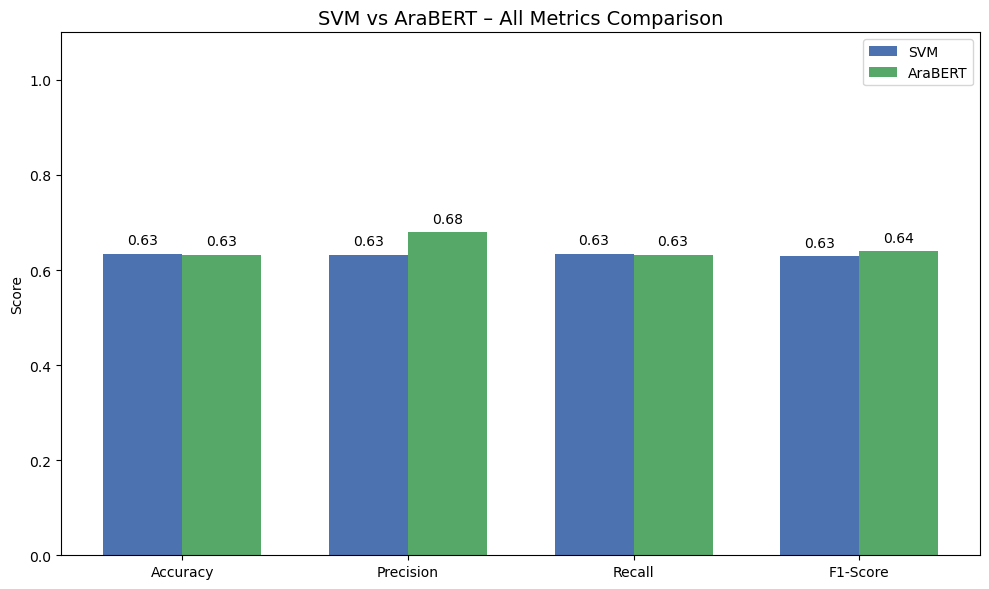

تم حفظ الرسم البياني 


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_vals  = [svm_metrics[m]  for m in metrics]
bert_vals = [bert_metrics[m] for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, svm_vals,  width, label='SVM',     color='#4C72B0')
bars2 = ax.bar(x + width/2, bert_vals, width, label='AraBERT', color='#55A868')

ax.set_title('SVM vs AraBERT – All Metrics Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\comparison_all_metrics.png")
plt.show()
print("تم حفظ الرسم البياني")



**Error Analysis - Both Models**

In [ ]:
label_names = {0: 'Negative', 1: 'Mixed', 2: 'Positive'}

svm_results = pd.DataFrame({
    'text':           X_test_small.tolist(),
    'actual':         y_test_small.tolist(),
    'svm_predicted':  svm_preds_small.tolist(),
    'bert_predicted': all_preds,
})
svm_results['actual_label']    = svm_results['actual'].map(label_names)
svm_results['svm_pred_label']  = svm_results['svm_predicted'].map(label_names)
svm_results['bert_pred_label'] = svm_results['bert_predicted'].map(label_names)

svm_errors  = svm_results[svm_results['actual'] != svm_results['svm_predicted']]
bert_errors = svm_results[svm_results['actual'] != svm_results['bert_predicted']]

print(f"\n=== Error Analysis (على 500 sample مشتركة) ===")
print(f"SVM   عدد الأخطاء: {len(svm_errors)}  ({len(svm_errors)/500:.1%})")
print(f"AraBERT عدد الأخطاء: {len(bert_errors)}  ({len(bert_errors)/500:.1%})")

print(f"\nSVM توزيع الأخطاء:")
print(svm_errors['actual_label'].value_counts())

print(f"\nAraBERT توزيع الأخطاء:")
print(bert_errors['actual_label'].value_counts())

print(f"\n=== أمثلة أخطاء فئة Mixed - AraBERT ===")
mixed_errors = bert_errors[bert_errors['actual_label'] == 'Mixed']
print(mixed_errors[['text', 'actual_label', 'bert_pred_label']].head(5).to_string(index=False))

svm_results.to_csv(
    r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\error_analysis.csv",
    index=False, encoding='utf-8-sig')
print("\nتم حفظ ملف Error Analysis")


=== Error Analysis (على 500 sample مشتركة) ===
SVM  عدد الأخطاء: 183  (36.6%)
AraBERT عدد الأخطاء: 184  (36.8%)

SVM توزيع الأخطاء حسب الفئة الفعلية:
actual_label
Mixed       89
Negative    53
Positive    41
Name: count, dtype: int64

AraBERT توزيع الأخطاء حسب الفئة الفعلية:
actual_label
Negative    69
Positive    67
Mixed       48
Name: count, dtype: int64

=== أمثلة أخطاء فئة Mixed AraBERT ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                 text actual_label bert_pred_label
رواية الفيل الءزرق جيدة ءلى حد والتوصيف قادر بث الدهشة ءحيانا للءسف الحبكة مفككة ولامنطقية الءحداث تسيطر تظهر بوضوح جلي لمسات صنع الل

**Save Results**

In [ ]:
svm_results.to_csv(
    r"C:\Users\shaha\OneDrive\Desktop\PSAU\Third semeter\Text Mining\Project\results.csv",
    index=False, encoding='utf-8-sig')

print("تم حفظ كل النتائج ✅")
print("\n=== ملخص المشروع ===")
print(f"SVM Accuracy:     {svm_metrics['Accuracy']:.0%}")
print(f"AraBERT Accuracy: {bert_metrics['Accuracy']:.0%}")
print(f"الداتاسيت:        99,999 ريفيو عربي")
print(f"النماذج:          SVM + AraBERT")
print(f"المهمة:           Sentiment Analysis")

تم حفظ كل النتائج 

=== ملخص المشروع ===
SVM Accuracy:     63%
AraBERT Accuracy: 63%
الداتاسيت:        99,999 ريفيو عربي
النماذج:          SVM + AraBERT
المهمة:           Sentiment Analysis
